In [1]:
!pip install pyspark

In [2]:
import pyspark
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder.getOrCreate()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Conexão com o CSV bruto de plataforma de streamings

df = spark.read.csv("/content/drive/MyDrive/Projeto Final - EBAC - Análise de Dados/csvs/plataformastreamings.csv", header=True, inferSchema=True)

In [6]:
# Exploração inicial do csv bruto de plataforma de streamings - colunas

df.columns
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten Tomatoes: string (nullable = true)
 |-- Netflix: integer (nullable = true)
 |-- Hulu: integer (nullable = true)
 |-- Prime Video: integer (nullable = true)
 |-- Disney+: integer (nullable = true)
 |-- Type: integer (nullable = true)



In [7]:
# Verificar linhas e contar registros

df.show(10, truncate=False)
df.count()

+---+---+----------------------------------------+----+---+---------------+-------+----+-----------+-------+----+
|_c0|ID |Title                                   |Year|Age|Rotten Tomatoes|Netflix|Hulu|Prime Video|Disney+|Type|
+---+---+----------------------------------------+----+---+---------------+-------+----+-----------+-------+----+
|0  |1  |The Irishman                            |2019|18+|98/100         |1      |0   |0          |0      |0   |
|1  |2  |Dangal                                  |2016|7+ |97/100         |1      |0   |0          |0      |0   |
|2  |3  |David Attenborough: A Life on Our Planet|2020|7+ |95/100         |1      |0   |0          |0      |0   |
|3  |4  |Lagaan: Once Upon a Time in India       |2001|7+ |94/100         |1      |0   |0          |0      |0   |
|4  |5  |Roma                                    |2018|18+|94/100         |1      |0   |0          |0      |0   |
|5  |6  |To All the Boys I've Loved Before       |2018|13+|94/100         |1      |0   |

9515

In [8]:
# Verificar nulos e strings vazias

from pyspark.sql.functions import col, count, when, trim

df.select([
    count(
        when(
            col(c).isNull() | (trim(col(c).cast("string")) == ""),
            c
        )
    ).alias(c)
    for c in df.columns
]).show(truncate=False)

+---+---+-----+----+----+---------------+-------+----+-----------+-------+----+
|_c0|ID |Title|Year|Age |Rotten Tomatoes|Netflix|Hulu|Prime Video|Disney+|Type|
+---+---+-----+----+----+---------------+-------+----+-----------+-------+----+
|0  |0  |0    |0   |4177|7              |0      |0   |0          |0      |0   |
+---+---+-----+----+----+---------------+-------+----+-----------+-------+----+



In [9]:
# Remover coluna c_0 e type

df = df.drop("_c0", "Type")
df.columns

['ID',
 'Title',
 'Year',
 'Age',
 'Rotten Tomatoes',
 'Netflix',
 'Hulu',
 'Prime Video',
 'Disney+']

In [10]:
# Filtar Netflix e Disney+

df_filtrado = df.filter(
    (df["Netflix"] == 1) |
    (df["Disney+"] == 1)
)

df_filtrado.count()

4611

In [11]:
# Verificar o df filtrado

df_filtrado.show(10, truncate=False)
df_filtrado.printSchema()

+---+----------------------------------------+----+---+---------------+-------+----+-----------+-------+
|ID |Title                                   |Year|Age|Rotten Tomatoes|Netflix|Hulu|Prime Video|Disney+|
+---+----------------------------------------+----+---+---------------+-------+----+-----------+-------+
|1  |The Irishman                            |2019|18+|98/100         |1      |0   |0          |0      |
|2  |Dangal                                  |2016|7+ |97/100         |1      |0   |0          |0      |
|3  |David Attenborough: A Life on Our Planet|2020|7+ |95/100         |1      |0   |0          |0      |
|4  |Lagaan: Once Upon a Time in India       |2001|7+ |94/100         |1      |0   |0          |0      |
|5  |Roma                                    |2018|18+|94/100         |1      |0   |0          |0      |
|6  |To All the Boys I've Loved Before       |2018|13+|94/100         |1      |0   |0          |0      |
|7  |The Social Dilemma                      |2020|13+|

In [12]:
# Verificar a distribuição das plataformas Netflix e Disney+

df_filtrado.groupBy("Netflix", "Disney+").count().show()

+-------+-------+-----+
|Netflix|Disney+|count|
+-------+-------+-----+
|      1|      0| 3689|
|      1|      1|    6|
|      0|      1|  916|
+-------+-------+-----+



In [13]:
# Remover Hulu e PrimeVideo

df_filtrado = df_filtrado.drop("Hulu", "Prime Video")

In [14]:
# Dsitribuição por ano

df_filtrado.groupBy("Year") \
    .count() \
    .orderBy("Year") \
    .show(100, truncate=False)

+----+-----+
|Year|count|
+----+-----+
|1922|1    |
|1923|1    |
|1928|1    |
|1932|3    |
|1933|3    |
|1934|5    |
|1935|4    |
|1936|6    |
|1937|6    |
|1938|5    |
|1939|6    |
|1940|5    |
|1941|8    |
|1942|7    |
|1943|1    |
|1944|2    |
|1946|2    |
|1947|5    |
|1948|5    |
|1949|5    |
|1950|5    |
|1951|4    |
|1952|8    |
|1953|6    |
|1954|6    |
|1955|9    |
|1956|4    |
|1957|4    |
|1958|2    |
|1959|7    |
|1960|2    |
|1961|3    |
|1962|3    |
|1963|4    |
|1964|5    |
|1965|4    |
|1966|2    |
|1967|2    |
|1968|2    |
|1969|4    |
|1970|2    |
|1971|5    |
|1972|4    |
|1973|2    |
|1974|6    |
|1975|7    |
|1976|7    |
|1977|8    |
|1978|5    |
|1979|13   |
|1980|8    |
|1981|9    |
|1982|10   |
|1983|5    |
|1984|11   |
|1985|8    |
|1986|13   |
|1987|10   |
|1988|14   |
|1989|12   |
|1990|16   |
|1991|12   |
|1992|17   |
|1993|20   |
|1994|20   |
|1995|19   |
|1996|13   |
|1997|24   |
|1998|35   |
|1999|25   |
|2000|28   |
|2001|35   |
|2002|37   |
|2003|46   |

In [15]:
# Distribuição por classificação indicativa

df_filtrado.groupBy("Age") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+----+-----+
|Age |count|
+----+-----+
|NULL|1991 |
|18+ |880  |
|7+  |598  |
|all |513  |
|13+ |474  |
|16+ |155  |
+----+-----+



In [16]:
# Converter null de age para "não informado"

from pyspark.sql.functions import when, col

df_filtrado = df_filtrado.withColumn(
    "Age",
    when(col("Age").isNull(), "Não informado")
    .otherwise(col("Age"))
)

In [17]:
# Verificar a conversão null de age para "não informado"

df_filtrado.groupBy("Age") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(truncate=False)

+-------------+-----+
|Age          |count|
+-------------+-----+
|Não informado|1991 |
|18+          |880  |
|7+           |598  |
|all          |513  |
|13+          |474  |
|16+          |155  |
+-------------+-----+



In [18]:
# Criar coluna numérica para Rotten Tomatoes

from pyspark.sql.functions import regexp_extract, col

df_filtrado = df_filtrado.withColumn(
    "Rotten_Tomatoes_Score",
    regexp_extract(col("Rotten Tomatoes"), r"(\d+)", 1).cast("int")
)

In [19]:
# Verificar a criação da coluna numérica para Rotten Tomatoes

df_filtrado.select(
    "Title",
    "Rotten Tomatoes",
    "Rotten_Tomatoes_Score"
).show(10, truncate=False)

+----------------------------------------+---------------+---------------------+
|Title                                   |Rotten Tomatoes|Rotten_Tomatoes_Score|
+----------------------------------------+---------------+---------------------+
|The Irishman                            |98/100         |98                   |
|Dangal                                  |97/100         |97                   |
|David Attenborough: A Life on Our Planet|95/100         |95                   |
|Lagaan: Once Upon a Time in India       |94/100         |94                   |
|Roma                                    |94/100         |94                   |
|To All the Boys I've Loved Before       |94/100         |94                   |
|The Social Dilemma                      |93/100         |93                   |
|Okja                                    |92/100         |92                   |
|The Ballad of Buster Scruggs            |92/100         |92                   |
|The Trial of the Chicago 7 

In [20]:
# Verificar se Rotten Tomatoes ficou numérico

df_filtrado.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten Tomatoes: string (nullable = true)
 |-- Netflix: integer (nullable = true)
 |-- Disney+: integer (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)



In [21]:
# Remover a coluna Rotten Tomatoes

df_filtrado = df_filtrado.drop("Rotten Tomatoes")
df_filtrado.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Netflix: integer (nullable = true)
 |-- Disney+: integer (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)



In [22]:
# Criar tabela títulos

tabela_titulos = df_filtrado.select(
    "ID",
    "Title",
    "Year",
    "Age",
    "Rotten_Tomatoes_Score"
)

tabela_titulos.show(10, truncate=False)
tabela_titulos.count()

+---+----------------------------------------+----+---+---------------------+
|ID |Title                                   |Year|Age|Rotten_Tomatoes_Score|
+---+----------------------------------------+----+---+---------------------+
|1  |The Irishman                            |2019|18+|98                   |
|2  |Dangal                                  |2016|7+ |97                   |
|3  |David Attenborough: A Life on Our Planet|2020|7+ |95                   |
|4  |Lagaan: Once Upon a Time in India       |2001|7+ |94                   |
|5  |Roma                                    |2018|18+|94                   |
|6  |To All the Boys I've Loved Before       |2018|13+|94                   |
|7  |The Social Dilemma                      |2020|13+|93                   |
|8  |Okja                                    |2017|13+|92                   |
|9  |The Ballad of Buster Scruggs            |2018|16+|92                   |
|10 |The Trial of the Chicago 7              |2020|18+|92       

4611

In [23]:
# Criar tabela de plataformas (Netflix e Disney+)

from pyspark.sql.functions import array, struct, explode, lit, col

tabela_plataformas = df_filtrado.select(
    col("ID"),
    explode(
        array(
            struct(lit("Netflix").alias("Plataforma"), col("Netflix").alias("Disponivel")),
            struct(lit("Disney+").alias("Plataforma"), col("Disney+").alias("Disponivel"))
        )
    ).alias("plataforma_info")
).select(
    col("ID"),
    col("plataforma_info.Plataforma"),
    col("plataforma_info.Disponivel")
).filter(
    col("Disponivel") == 1
).drop("Disponivel")

tabela_plataformas.show(20, truncate=False)
tabela_plataformas.count()

+---+----------+
|ID |Plataforma|
+---+----------+
|1  |Netflix   |
|2  |Netflix   |
|3  |Netflix   |
|4  |Netflix   |
|5  |Netflix   |
|6  |Netflix   |
|7  |Netflix   |
|8  |Netflix   |
|9  |Netflix   |
|10 |Netflix   |
|11 |Netflix   |
|12 |Netflix   |
|13 |Netflix   |
|14 |Netflix   |
|15 |Netflix   |
|16 |Netflix   |
|17 |Netflix   |
|18 |Netflix   |
|19 |Netflix   |
|20 |Netflix   |
+---+----------+
only showing top 20 rows


4617

In [24]:
# Filtrar top 150 títulos

top150 = df_filtrado.orderBy(
    df_filtrado["Rotten_Tomatoes_Score"].desc()
).limit(150)

In [25]:
# Criar estrutura para tabela_acessibilidade

from pyspark.sql.functions import lit

tabela_acessibilidade_base = top150.select(
    "ID",
    "Title"
).withColumn(
    "Possui_CC", lit(None)
).withColumn(
    "Possui_SDH", lit(None)
).withColumn(
    "Possui_AD", lit(None)
).withColumn(
    "Idiomas_CC", lit(None)
).withColumn(
    "Idiomas_AD", lit(None)
)

In [26]:
# Salvar tabela_acessibilidade_base

tabela_acessibilidade_base.toPandas().to_csv(
    "/content/drive/MyDrive/Projeto Final - EBAC - Análise de Dados/csvs/tabela_acessibilidade_base.csv",
    index=False
)

Desenvolvimento dos gráficos para o relatório


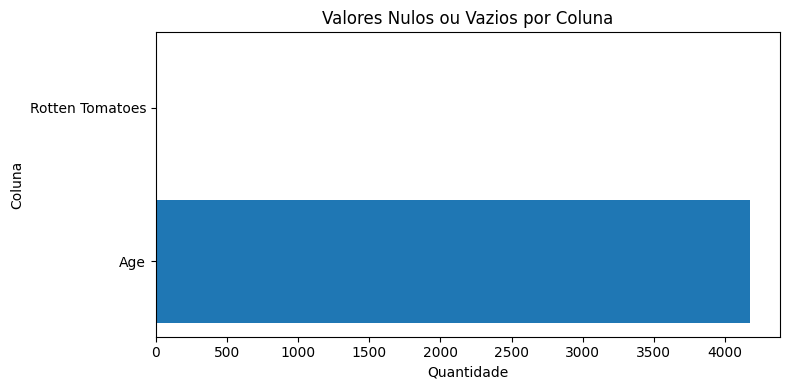

In [27]:
# Geração de gráficos para insights

# 1 - Qualidade dos dados (nulos/vazios)

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, count, when, trim

# Contagem de nulos/vazios
nulos_df = df.select([
    count(
        when(
            col(c).isNull() | (trim(col(c).cast("string")) == ""),
            c
        )
    ).alias(c)
    for c in df.columns
]).toPandas().T.reset_index()

nulos_df.columns = ["Coluna", "Nulos_Vazios"]

# Filtrar apenas colunas com nulos
nulos_df = nulos_df[nulos_df["Nulos_Vazios"] > 0]

# Gráfico
plt.figure(figsize=(8,4))
plt.barh(nulos_df["Coluna"], nulos_df["Nulos_Vazios"])

plt.title("Valores Nulos ou Vazios por Coluna")
plt.xlabel("Quantidade")
plt.ylabel("Coluna")

plt.tight_layout()
plt.show()

A análise inicial identificou inconsistências e ausência de dados em algumas colunas, principalmente em *Age,* indicando necessidade de tratamento antes da modelagem final. Também foram identificadas colunas pouco relevantes para o escopo do projeto, como _c0 e Type.

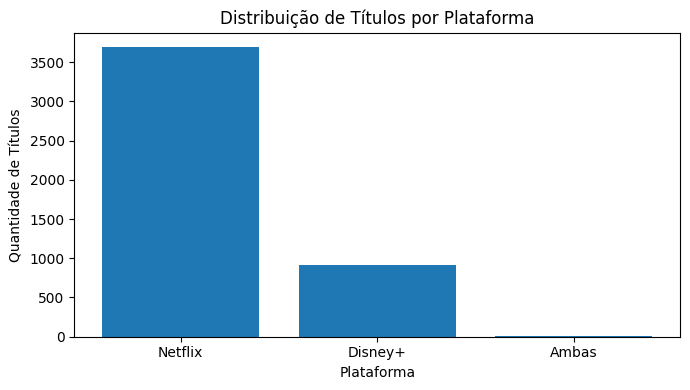

In [28]:
# 2 - Distribuição por plataforma

# Dados das plataformas
plataformas = {
    "Netflix": 3689,
    "Disney+": 916,
    "Ambas": 6
}

# Criar DataFrame pandas
plataformas_df = pd.DataFrame(
    list(plataformas.items()),
    columns=["Plataforma", "Quantidade"]
)

# Gráfico
plt.figure(figsize=(7,4))

plt.bar(
    plataformas_df["Plataforma"],
    plataformas_df["Quantidade"]
)

plt.title("Distribuição de Títulos por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Quantidade de Títulos")

plt.tight_layout()
plt.show()

A análise inicial mostrou predominância significativa de títulos disponíveis na Netflix em comparação ao Disney+. Também foi identificado um número muito pequeno de títulos compartilhados entre as plataformas, indicando baixa sobreposição de catálogo dentro da amostra analisada.

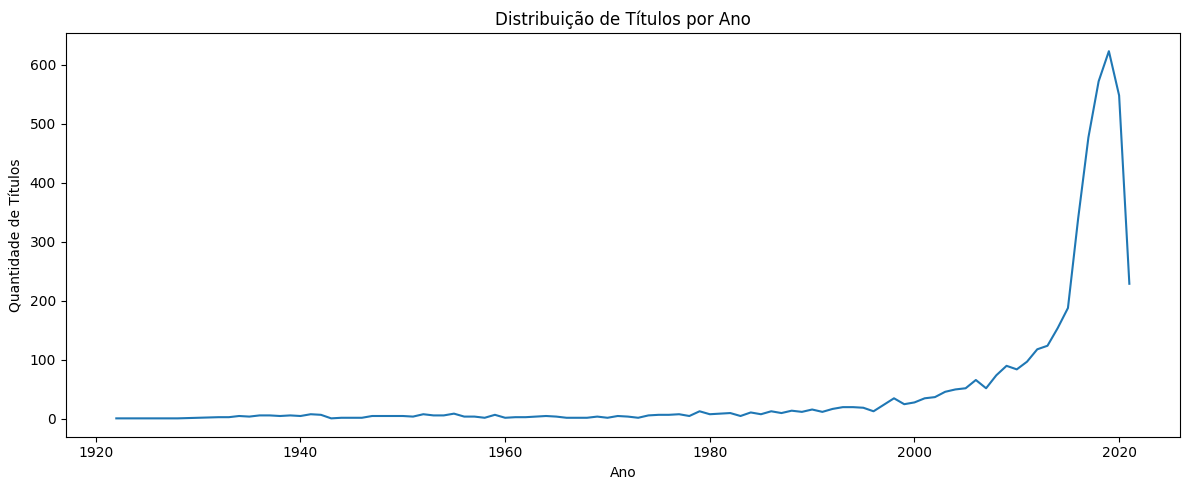

In [29]:
# 3 - Distribuição temporal

# Converter para pandas
anos_df = (
    df_filtrado
    .groupBy("Year")
    .count()
    .orderBy("Year")
    .toPandas()
)

# Gráfico
plt.figure(figsize=(12,5))

plt.plot(
    anos_df["Year"],
    anos_df["count"]
)

plt.title("Distribuição de Títulos por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Títulos")

plt.tight_layout()
plt.show()


A distribuição temporal dos títulos demonstrou crescimento significativo do catálogo a partir da **década de 2010,** com forte concentração entre 2015 e 2020. Esse comportamento acompanha a expansão das plataformas de streaming e o aumento da produção/distribuição de conteúdo digital nos últimos anos.

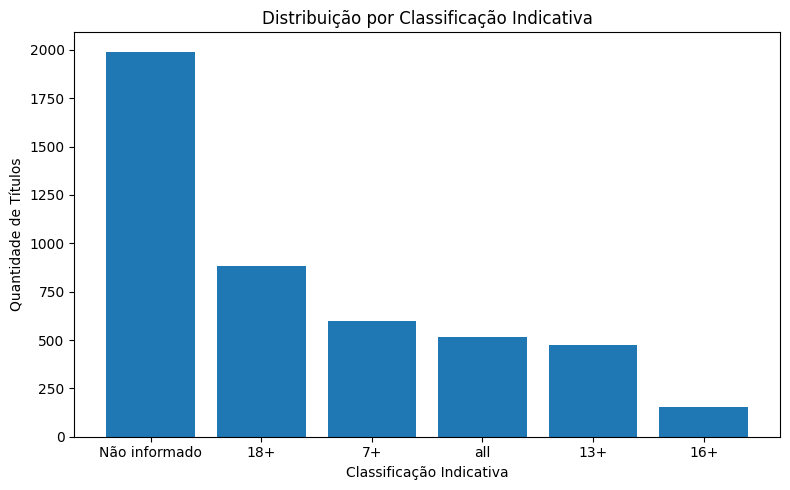

In [30]:
# 4 - Classificação indicativa

# Converter para pandas
age_df = (
    df_filtrado
    .groupBy("Age")
    .count()
    .orderBy("count", ascending=False)
    .toPandas()
)

# Substituir nulos apenas para visualização
age_df["Age"] = age_df["Age"].fillna("Não informado")

# Gráfico
plt.figure(figsize=(8,5))

plt.bar(
    age_df["Age"],
    age_df["count"]
)

plt.title("Distribuição por Classificação Indicativa")
plt.xlabel("Classificação Indicativa")
plt.ylabel("Quantidade de Títulos")

plt.tight_layout()
plt.show()

A análise da classificação indicativa mostrou predominância de conteúdos voltados ao público adulto (18+), além de uma quantidade significativa de títulos sem classificação informada. Esse comportamento evidencia inconsistências na qualidade dos dados e reforça a necessidade de tratamento antes da modelagem final.

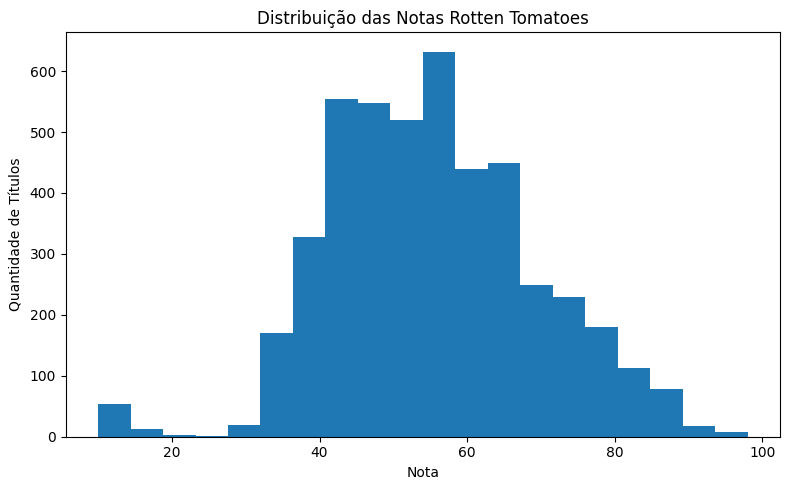

In [31]:
from pyspark.sql.functions import col

# Extrair apenas o número da nota
rt_df = (
    df_filtrado
    .select("Rotten_Tomatoes_Score")
    .dropna()
    .toPandas()
)

# Gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(
    rt_df["Rotten_Tomatoes_Score"],
    bins=20
)

plt.title("Distribuição das Notas Rotten Tomatoes")
plt.xlabel("Nota")
plt.ylabel("Quantidade de Títulos")

plt.tight_layout()
plt.show()

A distribuição das avaliações Rotten Tomatoes demonstrou concentração de títulos em faixas intermediárias e altas de avaliação. Durante a exploração inicial, também foi identificado que a coluna estava armazenada em formato textual (98/100), exigindo transformação para utilização analítica posterior.

############################################################################

In [32]:
# Importar tabela_acessibilidade_base

df_acessibilidade = spark.read.csv("/content/drive/MyDrive/Projeto Final - EBAC - Análise de Dados/csvs/tabela_acessibilidade_base - tabela_acessibilidade_base.csv", header=True, inferSchema=True)

df_acessibilidade.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Possui_CC: string (nullable = true)
 |-- Possui_SDH: string (nullable = true)
 |-- Possui_AD: string (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: string (nullable = true)



In [33]:
# Validar valores distintos

df_acessibilidade.select(
    "Possui_CC",
    "Possui_SDH",
    "Possui_AD",
    "Legendas_Simples_PT"
).distinct().show(50, truncate=False)

+---------+----------+---------+-------------------+
|Possui_CC|Possui_SDH|Possui_AD|Legendas_Simples_PT|
+---------+----------+---------+-------------------+
|0        |1         |1        |1                  |
|null     |null      |null     |1                  |
|1        |0         |1        |0                  |
|0        |0         |1        |1                  |
|0        |1         |0        |1                  |
|1        |0         |1        |1                  |
|null     |null      |null     |null               |
|1        |1         |1        |1                  |
|0        |0         |0        |1                  |
+---------+----------+---------+-------------------+



In [34]:
df_acessibilidade.show(10, truncate=False)

+----+----------------------------------------+---------+----------+---------+-----------+----------+----------------+-------------------+
|ID  |Title                                   |Possui_CC|Possui_SDH|Possui_AD|Idiomas_SDH|Idiomas_CC|Idiomas_AD      |Legendas_Simples_PT|
+----+----------------------------------------+---------+----------+---------+-----------+----------+----------------+-------------------+
|1   |The Irishman                            |0        |1         |1        |inglês     |0         |português       |1                  |
|2   |Dangal                                  |0        |0         |0        |0          |0         |0               |1                  |
|8616|Mary Poppins                            |0        |1         |1        |inglês     |0         |inglês          |1                  |
|3   |David Attenborough: A Life on Our Planet|0        |1         |1        |inglês     |0         |inglês          |1                  |
|4   |Lagaan: Once Upon a T

In [35]:
# Transformar (Possui_CC, Possui_SDH, Possui_AD, Legendas_Simples_PT) em número inteiro

from pyspark.sql.functions import col, when

colunas = [
    "Possui_CC",
    "Possui_SDH",
    "Possui_AD",
    "Legendas_Simples_PT"
]

for c in colunas:
    df_acessibilidade = df_acessibilidade.withColumn(
        c,
        when(col(c) == "null", None)
        .otherwise(col(c).cast("int"))
    )

In [36]:
# Verificar transformação

df_acessibilidade.printSchema()
df_acessibilidade.show(10, truncate=False)

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Possui_CC: integer (nullable = true)
 |-- Possui_SDH: integer (nullable = true)
 |-- Possui_AD: integer (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: integer (nullable = true)

+----+----------------------------------------+---------+----------+---------+-----------+----------+----------------+-------------------+
|ID  |Title                                   |Possui_CC|Possui_SDH|Possui_AD|Idiomas_SDH|Idiomas_CC|Idiomas_AD      |Legendas_Simples_PT|
+----+----------------------------------------+---------+----------+---------+-----------+----------+----------------+-------------------+
|1   |The Irishman                            |0        |1         |1        |inglês     |0         |português       |1                  |
|2   |Dangal                                  |0        |0  

In [37]:
# Padronizar os null

from pyspark.sql.functions import col, when

colunas_idiomas = [
    "Idiomas_SDH",
    "Idiomas_CC",
    "Idiomas_AD"
]

for c in colunas_idiomas:
    df_acessibilidade = df_acessibilidade.withColumn(
        c,
        when(col(c) == "null", None)
        .otherwise(col(c))
    )

In [38]:
# Verificação da padronização

df_acessibilidade.printSchema()
df_acessibilidade.show(10, truncate=False)

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Possui_CC: integer (nullable = true)
 |-- Possui_SDH: integer (nullable = true)
 |-- Possui_AD: integer (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: integer (nullable = true)

+----+----------------------------------------+---------+----------+---------+-----------+----------+----------------+-------------------+
|ID  |Title                                   |Possui_CC|Possui_SDH|Possui_AD|Idiomas_SDH|Idiomas_CC|Idiomas_AD      |Legendas_Simples_PT|
+----+----------------------------------------+---------+----------+---------+-----------+----------+----------------+-------------------+
|1   |The Irishman                            |0        |1         |1        |inglês     |0         |português       |1                  |
|2   |Dangal                                  |0        |0  

In [39]:
# Verificar contagem

df_acessibilidade.count()
df_acessibilidade.select("ID").distinct().count()

150

In [40]:
# Verificação contagem e shcema tabela títulos

tabela_titulos.printSchema()
tabela_titulos.count()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)



4611

In [41]:
tabela_titulos.select("ID").distinct().count()

4611

In [42]:
# Verificação tabela plataformas

tabela_plataformas.printSchema()
tabela_plataformas.count()

root
 |-- ID: integer (nullable = true)
 |-- Plataforma: string (nullable = false)



4617

In [43]:
tabela_plataformas.select("ID").distinct().count()

4611

In [44]:
# Base para o join

base_titulos_acessibilidade = tabela_titulos.join(
    df_acessibilidade,
    on="ID",
    how="inner")

base_titulos_acessibilidade.count()

150

In [45]:
# Verificação visual da base

base_titulos_acessibilidade.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Possui_CC: integer (nullable = true)
 |-- Possui_SDH: integer (nullable = true)
 |-- Possui_AD: integer (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: integer (nullable = true)



In [46]:
# Remover Title da tabela acessibilidade para não duplicar no join

df_acessibilidade_sem_title = df_acessibilidade.drop("Title")

In [47]:
# Join das tabelas

base_titulos_acessibilidade = tabela_titulos.join(
    df_acessibilidade_sem_title,
    on="ID",
    how="inner")

In [48]:
# Verificação do join

base_titulos_acessibilidade.printSchema()
base_titulos_acessibilidade.count()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)
 |-- Possui_CC: integer (nullable = true)
 |-- Possui_SDH: integer (nullable = true)
 |-- Possui_AD: integer (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: integer (nullable = true)



150

In [49]:
# Join para a base final

base_final = base_titulos_acessibilidade.join(
    tabela_plataformas,
    on="ID",
    how="left")

In [50]:
# Verificação

base_final.printSchema()
base_final.count()
base_final.show(10, truncate=False)

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)
 |-- Possui_CC: integer (nullable = true)
 |-- Possui_SDH: integer (nullable = true)
 |-- Possui_AD: integer (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: integer (nullable = true)
 |-- Plataforma: string (nullable = true)

+---+----------------------------------------+----+---+---------------------+---------+----------+---------+-----------+----------+----------------+-------------------+----------+
|ID |Title                                   |Year|Age|Rotten_Tomatoes_Score|Possui_CC|Possui_SDH|Possui_AD|Idiomas_SDH|Idiomas_CC|Idiomas_AD      |Legendas_Simples_PT|Plataforma|
+---+----------------------------------------+----+---+---------------------+---------+-

In [51]:
# Verificação de toda a integração (joins) da base final

base_final.count()

150

In [52]:
# Criação da coluna 1 Total_Recursos

from pyspark.sql.functions import coalesce, lit

base_final = base_final.withColumn(
    "Total_Recursos",
    coalesce(base_final.Possui_CC, lit(0))
    + coalesce(base_final.Possui_SDH, lit(0))
    + coalesce(base_final.Possui_AD, lit(0)))

In [53]:
# Criação da coluna 2 Nivel_Acessibilidade

from pyspark.sql.functions import when, col

base_final = base_final.withColumn(
    "Nivel_Acessibilidade",
    when(
        col("Possui_CC").isNull() &
        col("Possui_SDH").isNull() &
        col("Possui_AD").isNull(),
        "Nao_Verificado"
    )
    .when(col("Total_Recursos") == 0, "Nenhuma")
    .when(col("Total_Recursos") == 1, "Baixa")
    .when(col("Total_Recursos") == 2, "Media")
    .when(col("Total_Recursos") == 3, "Alta"))

In [54]:
# Verificação Nivel_acessibilidade

base_final.groupBy("Nivel_Acessibilidade") \
    .count() \
    .show()

+--------------------+-----+
|Nivel_Acessibilidade|count|
+--------------------+-----+
|                Alta|   20|
|               Media|   58|
|             Nenhuma|    7|
|               Baixa|   21|
|      Nao_Verificado|   44|
+--------------------+-----+



In [55]:
# Análise exploratória da base_final

# 1- Qual recurso aparece mais?

from pyspark.sql.functions import sum

base_final.select(
    sum("Possui_CC").alias("Total_CC"),
    sum("Possui_SDH").alias("Total_SDH"),
    sum("Possui_AD").alias("Total_AD")
).show()

+--------+---------+--------+
|Total_CC|Total_SDH|Total_AD|
+--------+---------+--------+
|      25|       93|      79|
+--------+---------+--------+



In [56]:
# 2 - Netflix e Disney+ têm comportamentos diferentes?

base_final.groupBy(
    "Plataforma",
    "Nivel_Acessibilidade"
).count().show()

+----------+--------------------+-----+
|Plataforma|Nivel_Acessibilidade|count|
+----------+--------------------+-----+
|   Netflix|                Alta|    4|
|   Disney+|      Nao_Verificado|    1|
|   Netflix|               Baixa|    3|
|   Disney+|               Baixa|   18|
|   Netflix|             Nenhuma|    7|
|   Netflix|               Media|   54|
|   Netflix|      Nao_Verificado|   43|
|   Disney+|               Media|    4|
|   Disney+|                Alta|   16|
+----------+--------------------+-----+



In [57]:
# 3 - Títulos com maiores notas de avaliação possuem mais recursos de acessibilidade?

from pyspark.sql.functions import avg

base_final.groupBy(
    "Nivel_Acessibilidade"
).agg(
    avg("Rotten_Tomatoes_Score").alias("Media_Rotten")
).show()

+--------------------+-----------------+
|Nivel_Acessibilidade|     Media_Rotten|
+--------------------+-----------------+
|                Alta|            86.45|
|               Media|87.55172413793103|
|             Nenhuma|89.14285714285714|
|               Baixa| 86.0952380952381|
|      Nao_Verificado| 85.8409090909091|
+--------------------+-----------------+



In [58]:
# 4 -  Existe alguma faixa etária com mais recursos acessíveis?

base_final.groupBy(
    "Age",
    "Nivel_Acessibilidade"
).count().show()

+-------------+--------------------+-----+
|          Age|Nivel_Acessibilidade|count|
+-------------+--------------------+-----+
|           7+|               Baixa|    9|
|          16+|      Nao_Verificado|    1|
|           7+|                Alta|    2|
|          16+|               Media|    7|
|          18+|      Nao_Verificado|   25|
|          18+|               Baixa|    3|
|          18+|               Media|   27|
|          all|                Alta|    3|
|          13+|                Alta|   13|
|          all|               Baixa|    7|
|           7+|             Nenhuma|    2|
|           7+|      Nao_Verificado|    5|
|           7+|               Media|    5|
|Não informado|      Nao_Verificado|    4|
|          all|             Nenhuma|    2|
|          13+|               Media|   12|
|          13+|               Baixa|    2|
|          18+|             Nenhuma|    2|
|          13+|      Nao_Verificado|    7|
|          all|      Nao_Verificado|    2|
+----------

In [59]:
# 5 - Quantos títulos tem mais de um recurso?

base_final.groupBy(
    "Total_Recursos"
).count().show()

+--------------+-----+
|Total_Recursos|count|
+--------------+-----+
|             1|   21|
|             3|   20|
|             2|   58|
|             0|   51|
+--------------+-----+



In [60]:
# Quantos títulos possuem CC; quantos possuem SDH; quantos possuem AD

from pyspark.sql.functions import sum

base_final.select(
    sum("Possui_CC").alias("Total_CC"),
    sum("Possui_SDH").alias("Total_SDH"),
    sum("Possui_AD").alias("Total_AD")
).show()

+--------+---------+--------+
|Total_CC|Total_SDH|Total_AD|
+--------+---------+--------+
|      25|       93|      79|
+--------+---------+--------+



In [61]:
# Verificar a base final

base_final.printSchema()
base_final.count()

root
 |-- ID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Age: string (nullable = true)
 |-- Rotten_Tomatoes_Score: integer (nullable = true)
 |-- Possui_CC: integer (nullable = true)
 |-- Possui_SDH: integer (nullable = true)
 |-- Possui_AD: integer (nullable = true)
 |-- Idiomas_SDH: string (nullable = true)
 |-- Idiomas_CC: string (nullable = true)
 |-- Idiomas_AD: string (nullable = true)
 |-- Legendas_Simples_PT: integer (nullable = true)
 |-- Plataforma: string (nullable = true)
 |-- Total_Recursos: integer (nullable = false)
 |-- Nivel_Acessibilidade: string (nullable = true)



150

In [62]:
# Salvar a base final em CSV

base_final.toPandas().to_csv(
    "/content/drive/MyDrive/Projeto Final - EBAC - Análise de Dados/csvs/base_final_acessibilidade.csv",
    index=False)

In [63]:
spark.stop()

In [64]:
# Base final integrada para análise de acessibilidade
# Contém:
# - Informações dos títulos
# - Plataforma
# - Recursos de acessibilidade
# - Colunas derivadas:
#     Total_Recursos
#     Nivel_Acessibilidade
#
# Total de registros: 150